## 02 - Data Preprocessing  

In [79]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import logging
from sklearn.model_selection import train_test_split
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
logging.getLogger().setLevel(logging.CRITICAL)

In [11]:
# Packages version
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'logging: {logging.__version__}')

pandas: 2.3.1
numpy: 2.2.6
matplotlib: 3.10.3
seaborn: 0.13.2
logging: 0.5.1.2


In [12]:
# Download latest version
path = kagglehub.dataset_download("cindybtari/survival-analysis-dataset")
print("Path to dataset files:", path)

csv_path = os.path.join(path, "dialysis survival dataset.csv")  
df = pd.read_csv(csv_path)

df.head()

Path to dataset files: /Users/michelgonzagadossantos/.cache/kagglehub/datasets/cindybtari/survival-analysis-dataset/versions/1


,event,time,age,begin,center,disease_diabetes,disease_hypert,disease_other,disease_renal
0,0,1,59,35,120,0,1,0,0
1,0,3,49,38,120,0,1,0,0
2,0,18,49,22,120,0,0,1,0
3,0,2,52,21,120,0,1,0,0
4,1,1,89,41,120,0,1,0,0


## **🛠️ Data Preparation**

Our data preparation pipeline includes the following steps:

- **Constant Feature Removal**: Eliminating variables with no variance.
- **Correlation Filter**: Removing highly correlated features to reduce multicollinearity.
- **Judgmental Filtering**: Excluding variables based on domain knowledge and expert judgment.
- **Feature Engineering**: Creating and transforming variables to improve model performance.


In [ ]:
# Data Split
df_train, df_aux = train_test_split(df, train_size=0.85, stratify=df['event'],random_state=42)
df_test, df_val = train_test_split(df_aux, test_size=0.5, stratify=df_aux['event'],random_state=42)


# Suponha que você tenha as colunas 'event' e 'time' no df
X_train = df_train.drop(columns=['event','time'])
y_train = Surv.from_dataframe(event='event', time='time', data=df_train)


In [31]:
# Constant Feature Removal
def Constant_Filter(df,threshold):
    return [col for col in df.columns if df[col].value_counts(normalize=True).max() >= threshold]

columns_to_drop = Constant_Filter(X_train,0.8)
columns_to_keep = X_train.columns.difference(columns_to_drop).tolist()

X_train_filtered_1 = X_train[columns_to_keep]

print(140*'-')
print('Constant Feature Removal')
print(140*'-')
print(f'Columns to Drop:{columns_to_drop}')
print(f'Columns to Keep:{columns_to_keep}')
print(140*'-')

--------------------------------------------------------------------------------------------------------------------------------------------
Constant Feature Removal
--------------------------------------------------------------------------------------------------------------------------------------------
Columns to Drop:['disease_diabetes', 'disease_other']
Columns to Keep:['age', 'begin', 'center', 'disease_hypert', 'disease_renal']
--------------------------------------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------------------------------------
Correlation Filter
--------------------------------------------------------------------------------------------------------------------------------------------
Columns to Drop:[]
Columns to Keep:['age', 'disease_renal', 'disease_hypert', 'begin', 'center']
--------------------------------------------------------------------------------------------------------------------------------------------


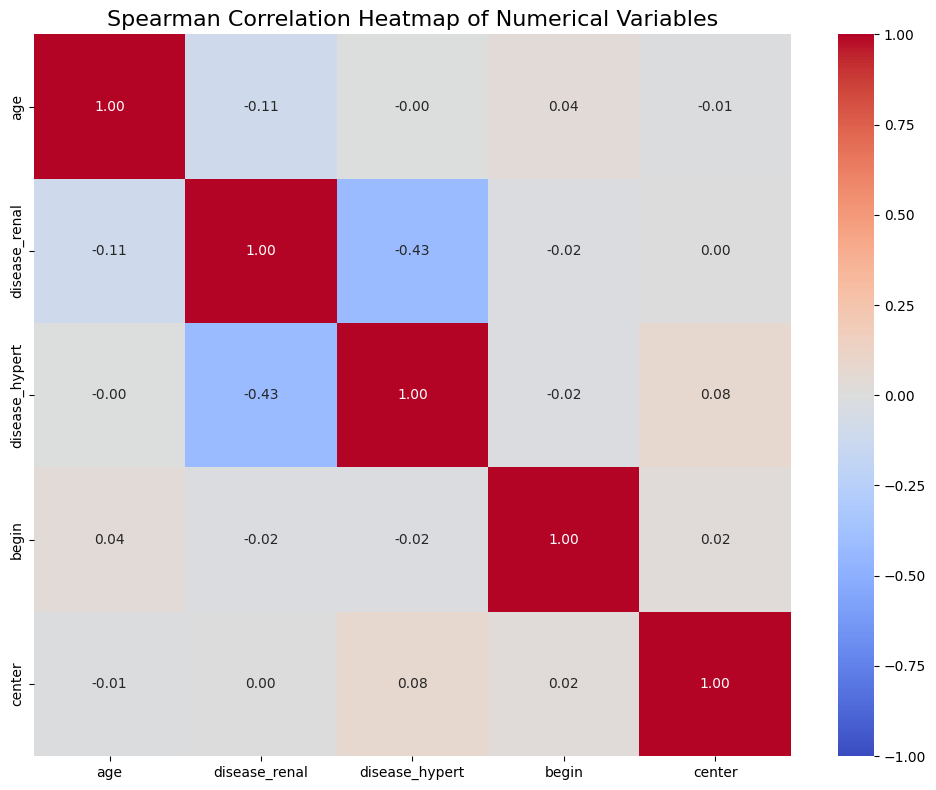

In [77]:
# Correlation Filter
def Correlation_Filter(df, threshold=0.66): 
    
    cols = set(df.columns)
    cor_mat = df.corr()
    
    for col1 in list(cols):
        for col2 in list(cols):
            if col1 != col2 and abs(cor_mat.at[col1, col2]) >= threshold:
                if col2 in cols:
                    cols.remove(col2)
                    
    return list(cols)

columns_to_keep = Correlation_Filter(X_train_filtered_1)
columns_to_drop = X_train_filtered_1.columns.difference(columns_to_keep).tolist()

X_train_filtered_2 = X_train_filtered_1[columns_to_keep]

print(140*'-')
print('Correlation Filter')
print(140*'-')
print(f'Columns to Drop:{columns_to_drop}')
print(f'Columns to Keep:{columns_to_keep}')
print(140*'-')

# Compute the correlation matrix
corr_matrix = X_train_filtered_2.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

## Judgmental Filter

In [78]:
X_train_filtered_3 = X_train_filtered_2.drop(columns=['center'])

In [82]:
X_test = df_test.drop(columns=['event','time'])
X_test = X_test[X_train_filtered_3.columns]
y_test = Surv.from_dataframe(event='event', time='time', data=df_test)

In [83]:
from sksurv.linear_model import CoxPHSurvivalAnalysis

model = CoxPHSurvivalAnalysis()
model.fit(X_train_filtered_3, y_train)

c_index = model.score(X_test, y_test)
print(f"Concordance Index (C-index): {c_index:.4f}")


Concordance Index (C-index): 0.6366


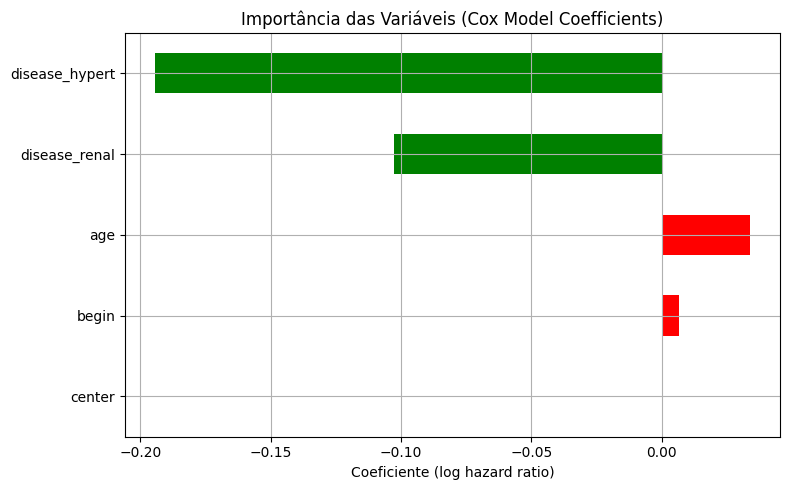

In [ ]:
# Coeficientes
coef_series = pd.Series(model.coef_, index=X_train_filtered_3.columns)

# Ordenar por importância absoluta
coef_series_sorted = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

# Visualizar
plt.figure(figsize=(8, 5))
coef_series_sorted.plot(kind='barh', color=np.where(coef_series_sorted > 0, 'red', 'green'))
plt.title("Importância das Variáveis (Cox Model Coefficients)")
plt.xlabel("Coeficiente (log hazard ratio)")
plt.grid(True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [38]:
hazard_ratios = np.exp(model.coef_)
hr_df = pd.DataFrame({
    "Feature": X_train_filtered_3.columns,
    "Hazard Ratio": hazard_ratios,
    "Coef": model.coef_
}).sort_values("Hazard Ratio", ascending=False)

print(hr_df)


          Feature  Hazard Ratio      Coef
0             age      1.034511  0.033929
3           begin      1.006600  0.006578
4          center      0.999988 -0.000012
1   disease_renal      0.902358 -0.102744
2  disease_hypert      0.823259 -0.194484


In [39]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# Instanciar o modelo
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

# Treinar
rsf.fit(X_train_filtered_3, y_train)

# Prever risco (maior valor = maior risco)
risk_scores_rsf = rsf.predict(X_test)

# Avaliar com C-index
c_index_rsf, *_ = concordance_index_censored(
    y_test["event"], y_test["time"], risk_scores_rsf
)

print(f"C-index (Random Survival Forest): {c_index_rsf:.4f}")

C-index (Random Survival Forest): 0.6860


In [40]:
from sksurv.ensemble import ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis

In [45]:
est_cph_tree = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
est_cph_tree.fit(X_train_filtered_3, y_train)
cindex = est_cph_tree.score(X_test, y_test)
print(round(cindex, 3))

0.702


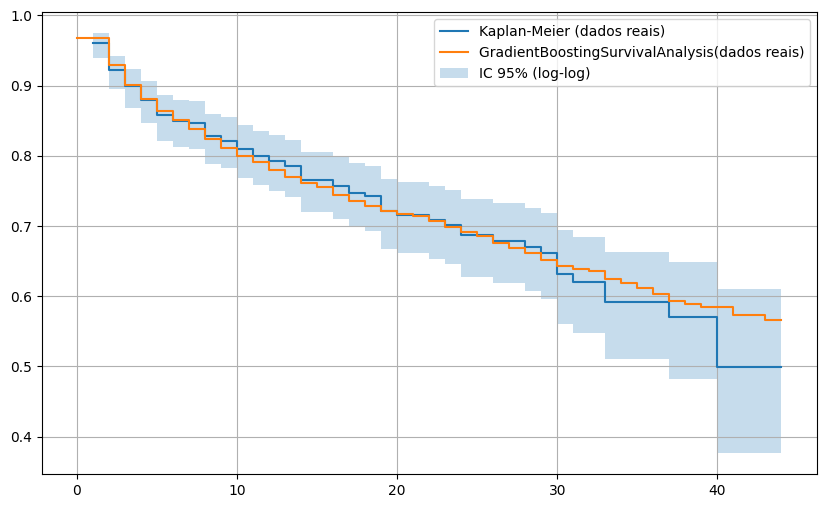

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

# === 1. Curva de Kaplan-Meier (dados reais) ===
# y_test deve estar no formato estruturado: array([(event, time), ...], dtype=[('event', bool), ('time', float)])
time_km, survival_prob, conf_int = kaplan_meier_estimator(
    y_test["event"], y_test["time"], conf_type="log-log"
)

# === 2. Funções de sobrevivência preditas pelo modelo ===
# Prever função de sobrevivência individual
surv_funcs = est_cph_tree.predict_survival_function(X_test)

# Encontrar o tempo máximo comum entre todas as funções
max_times = [fn.x[-1] for fn in surv_funcs]  # fn é do tipo StepFunction
max_common_time = int(np.floor(min(max_times)))

# Definir os tempos onde avaliar a média (domínio comum)
times = np.arange(0, max_common_time + 1)

# Avaliar todas as funções no vetor de tempos
surv_probs_matrix = np.vstack([
    fn(times) for fn in surv_funcs
])

# Calcular a função de sobrevivência média
mean_surv_func = np.mean(surv_probs_matrix, axis=0)

# === 3. Plot ===
plt.figure(figsize=(10, 6))

# Curva de Kaplan-Meier com IC
plt.step(time_km, survival_prob, where="post", label="Kaplan-Meier (dados reais)")
plt.step(times, mean_surv_func, where="post", label="GradientBoostingSurvivalAnalysis(dados reais)")
plt.fill_between(time_km, conf_int[0], conf_int[1], alpha=0.25, step="post", label="IC 95% (log-log)")
plt.legend()
plt.grid()
plt.show()
#
